
# 기본 환경 설정



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install sentence-transformers hdbscan umap-learn

In [3]:
!pip install konlpy kiwipiepy gensim scikit-learn seaborn tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 45.8 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.0-py3-none-any.whl size=79625203 sha256=7fbcbfa04b74ca4e896c7e62a1727dd36a46b83198545165c428ec1ca6a63eae
  Stored in directory: /root/.cache/pip/wheels/e5/4b/3f/aa850a40d0f9709fd4c6d37d48402ca95354264236e1205ea3
Successfully built kiwipiepy_model


In [4]:
import pandas as pd
import numpy as np
import time

import time, pickle, os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from konlpy.tag import Okt
from collections import Counter
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.cluster import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from tqdm.notebook import tqdm

import html
from sentence_transformers import SentenceTransformer


# 임베딩

In [5]:
#데이터 가져오기

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DX프로젝트/data/total_data.csv',encoding='utf-8-sig',index_col = 0)

In [6]:
df.head()

,date,content,contents,text,articles,article_words,re_article_words
0,2023. 9. 3. 16:41,"일하러 사무실에 나왔는데, 두시간동안 보조금 신청 관련 서류 6장 겨우 출력하고 계...",NaN,NaN,일하러 사무실에 나왔는데 두시간동안 보조금 신청 관련 서류 장 겨우 출력하고 계속 ...,"['일', '사무실', '시간', '동안', '보조금', '신청', '관련', '서...","['사무실', '시간', '동안', '보조금', '신청', '관련', '서류', '..."
1,2023. 9. 4. 8:50,사실 많은 사람들은 ADHD 문제는 대부분 어린아이에게만 해당이 된다고 생각을 하곤...,NaN,NaN,사실 많은 사람들은 ADHD 문제는 대부분 어린아이에게만 해당이 된다고 생각을 하곤...,"['사실', '사람', '문제', '대부분', '해당', '생각', '사실', '성...","['사실', '사람', '문제', '대부분', '해당', '생각', '사실', '성..."
2,2023. 8. 22. 15:49,성인 Adhd를 위한 조언\n-성인 ADHD와 함께 삶을 살아가는 것은 도전적일 수...,NaN,NaN,성인 Adhd를 위한 조언 성인 ADHD와 함께 삶을 살아가는 것은 도전적일 수 있...,"['성인', '를', '위', '조언', '성인', '삶', '것', '도전', '...","['성인', '조언', '성인', '도전', '가지', '조언', '정보', '습득..."
3,2023. 9. 1. 6:34,성인 ADHD 자가진단테스트 전문가 진행하는 것이 아니기 때문에 자가진단 도구라기보...,NaN,NaN,성인 ADHD 자가진단테스트 전문가 진행하는 것이 아니기 때문에 자가진단 도구라기보...,"['성인', '자가진단', '테스트', '전문가', '진행', '것', '때문', ...","['성인', '자가진단', '테스트', '전문가', '진행', '때문', '자가진단..."
4,2023. 8. 31. 21:10,흐름이 좀 흐트러졌다. 흐트러진 후 다시 궤도에 오르는 데 시간이 걸린다. 다시 돌...,NaN,NaN,흐름이 좀 흐트러졌다. 흐트러진 후 다시 궤도에 오르는 데 시간이 걸린다. 다시 돌...,"['흐름', '좀', '흐트러졌다', '흐트러진', '후', '다시', '궤도', ...","['흐름', '흐트러졌다', '흐트러진', '다시', '궤도', '시간', '다시'..."


In [7]:
#BERT모델

model = SentenceTransformer('jhgan/ko-sroberta-multitask')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
embeddings = model.encode(
    df['articles'],
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

#임베딩 벡터 저장
np.save("/content/drive/MyDrive/Colab Notebooks/DX프로젝트/data/bert_embeddings.npy", embeddings)

#호출은
#np.load()

Batches:   0%|          | 0/778 [00:00<?, ?it/s]

# 차원 축소 & 클러스터링

In [15]:
import hdbscan
import umap.umap_ as umap

def run_clustering(
    embeddings,
    n_neighbors=30,
    n_components=10,
    min_cluster_size=50,
    min_samples=None,
    metric='cosine'
):



    # 1) UMAP
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        metric=metric,
        random_state=42
    )
    emb_umap = umap_model.fit_transform(embeddings)

    # 2) HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, #클러스터 최소 크기
        min_samples=min_samples,
        metric='euclidean'
    )
    labels = clusterer.fit_predict(emb_umap)

    # 3) 클러스터 요약
    unique, counts = np.unique(labels, return_counts=True)
    cluster_info = pd.DataFrame({'label': unique, 'size': counts}).sort_values('size', ascending=False)

    print("노이즈 제외 클러스터 수:", (unique != -1).sum())
    print(cluster_info.head(10))

    return labels, cluster_info, emb_umap, clusterer

In [16]:
# 최종본

labels, info, emb_umap, clusterer = run_clustering(
    embeddings,
    n_neighbors=50, # 클수록: 전체 구조(글로벌)를 강조 → 덜 쪼개짐, 클러스터 수 줄어듦
    n_components=10,  #10 ~ 15정도 설정
    min_cluster_size=100, #클러스터의 최소 크기 설정
    min_samples=50 #값을 키울수록 클러스터 수는 줄고, 노이즈가 늘어남
)

노이즈 제외 클러스터 수: 2
   label   size
2      1  24534
1      0    267
0     -1     91


In [21]:
# 적당한 수의 클러스터로 나뉘면 저장

df['cluster_1v'] = labels

## 평가 (Davies-Bouldin Index)
### 클수록 군집이 안 좋고, 낮을수록 좋음.

In [13]:
from sklearn.metrics import davies_bouldin_score

def evaluate_hdbscan_clustering(emb_umap, labels, clusterer):
    """
    emb_umap  : UMAP으로 축소된 임베딩 (numpy array, shape = (N, d))
    labels    : HDBSCAN에서 나온 라벨 (numpy array, -1은 노이즈)
    clusterer : hdbscan.HDBSCAN 객체 (fit_predict까지 끝난 상태)
    """

    # 1) 노이즈 제거
    mask = labels != -1
    labels_clean = labels[mask]
    emb_umap_clean = emb_umap[mask]

    print(f"전체 샘플 수: {len(labels)}")
    print(f"노이즈 제외 샘플 수: {len(labels_clean)}")
    print(f"노이즈 비율: {(labels == -1).mean():.3f}")
    print()

    # 2) Davies-Bouldin Index 계산 (낮을수록 좋음)
    if len(np.unique(labels_clean)) > 1:
        dbi = davies_bouldin_score(emb_umap_clean, labels_clean)
        print(f"Davies-Bouldin Index (노이즈 제외): {dbi:.4f}")
    else:
        dbi = None
        print("Davies-Bouldin Index 계산 불가 (클러스터가 1개 이하입니다).")

    print()

    # 3) HDBSCAN cluster persistence(안정성) 정리
    #   - clusterer.cluster_persistence_: 각 클러스터의 지속성(0~1, 클수록 안정)
    #   - cluster 라벨: noise(-1)를 제외한 고유 라벨들
    unique_labels = np.unique(labels)
    unique_clusters = unique_labels[unique_labels != -1]

    if hasattr(clusterer, "cluster_persistence_"):
        persistence = clusterer.cluster_persistence_
        # persistence는 noise 제외한 클러스터 순서와 매칭됨
        cluster_stats = []

        for cl_label, pers in zip(unique_clusters, persistence):
            size = (labels == cl_label).sum()
            cluster_stats.append({
                "cluster": int(cl_label),
                "size": int(size),
                "persistence": float(pers)
            })

        cluster_df = pd.DataFrame(cluster_stats).sort_values(
            by=["persistence", "size"], ascending=False
        ).reset_index(drop=True)

        print("상위 클러스터 안정성 (persistence 기준 상위 10개):")
        print(cluster_df.head(10))

    else:
        cluster_df = None
        print("clusterer에 cluster_persistence_ 속성이 없습니다. HDBSCAN 객체인지 확인하세요.")

    return {
        "db_index": dbi,
        "cluster_summary": cluster_df
    }


In [17]:
result = evaluate_hdbscan_clustering(emb_umap, labels, clusterer)
result

전체 샘플 수: 24892
노이즈 제외 샘플 수: 24801
노이즈 비율: 0.004

Davies-Bouldin Index (노이즈 제외): 0.3558

상위 클러스터 안정성 (persistence 기준 상위 10개):
   cluster   size  persistence
0        0    267     0.742099
1        1  24534     0.080319


{'db_index': np.float64(0.3557982282303115),
 'cluster_summary':    cluster   size  persistence
 0        0    267     0.742099
 1        1  24534     0.080319}

In [25]:
#Cluster 1에 해당하는 cluster를 2차 클러스터링

# 1) 1차 결과에서 클러스터 1에 해당하는 문서만 마스크로 선택
mask_big = (labels == 1)

embeddings_big = embeddings[mask_big]   # BERT 임베딩 중 클러스터 1에 해당하는 것만
print("클러스터 1 문서 수:", embeddings_big.shape[0])

클러스터 1 문서 수: 24534


In [26]:
# 2) 클러스터 1 안에서만 다시 클러스터링
labels_big, info_big, emb_umap_big, clusterer_big = run_clustering(
    embeddings_big,
    n_neighbors=20,       # 좀 더 잘게 쪼개고 싶으면 10~20 정도
    n_components=10,
    min_cluster_size=50,  # 클러스터 1 내부에서 최소 크기 설정
    min_samples=10
)

print(info_big.head())


노이즈 제외 클러스터 수: 52
    label   size
0      -1  14016
41     40    845
21     20    818
16     15    549
18     17    480
24     23    448
35     34    412
34     33    388
23     22    387
48     47    369
    label   size
0      -1  14016
41     40    845
21     20    818
16     15    549
18     17    480


In [29]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from tqdm import tqdm

def search_best_super_clusters(X_docs, labels_2nd, k_range=range(2, 11), linkage='ward'):
    """
    X_docs    : 문서 임베딩 (예: emb_umap_big 또는 BERT 임베딩) shape = (N, d)
    labels_2nd: 2차 HDBSCAN 라벨 (-1 = 노이즈, 나머지 = 세부 클러스터 번호)
    k_range   : 합칠 상위 클러스터 개수 범위 (예: range(2, 11) → 2~10개)
    linkage   : AgglomerativeClustering linkage 방식 ('ward', 'average', 등)
    """

    # 1) 노이즈 제외
    mask = labels_2nd != -1
    X_clean = np.array(X_docs)[mask]          # (N_clean, d)
    labels_clean = labels_2nd[mask]

    # 2) 세부 클러스터별 센트로이드 계산
    unique_clusters = np.unique(labels_clean)  # 예: 0~51
    centroids = []
    for cl in unique_clusters:
        cl_points = X_clean[labels_clean == cl]
        centroids.append(cl_points.mean(axis=0))
    centroids = np.vstack(centroids)          # (num_clusters, d)

    results = []
    best_model_info = {}

    # 3) k(상위 클러스터 개수)를 바꿔가며 실루엣 스코어 계산
    for k in tqdm(k_range):
        # (1) 계층 클러스터링: 세부 클러스터 센트로이드를 k개 그룹으로 합침
        agg = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )
        super_for_clusters = agg.fit_predict(centroids)  # 각 세부 클러스터 → 상위 그룹 ID

        # (2) 세부 클러스터 라벨 → 상위 클러스터 라벨 매핑
        cluster_to_super = {
            int(cl): int(scl) for cl, scl in zip(unique_clusters, super_for_clusters)
        }

        # (3) 문서 단위 상위 라벨 생성
        super_labels_clean = np.zeros_like(labels_clean)
        for i, cl in enumerate(labels_clean):
            super_labels_clean[i] = cluster_to_super[int(cl)]

        # (4) 실루엣 스코어 계산
        #     (상위 클러스터가 2개 이상일 때만)
        if len(np.unique(super_labels_clean)) > 1:
            score = silhouette_score(X_clean, super_labels_clean, metric='euclidean')
        else:
            score = np.nan

        results.append({
            "n_super": k,
            "silhouette": score,
            "cluster_sizes": dict(zip(*np.unique(super_labels_clean, return_counts=True))),
            "cluster_to_super": cluster_to_super,
            "agg_model": agg
        })

        print(f"n_super={k}, silhouette={score:.4f}, 분포={results[-1]['cluster_sizes']}")

    # 4) 결과를 DataFrame으로 정리 (점수 비교용)
    df_scores = pd.DataFrame([
        {"n_super": r["n_super"], "silhouette": r["silhouette"]}
        for r in results
    ])

    # 가장 높은 실루엣 점수를 가진 설정 찾기
    best_idx = df_scores["silhouette"].idxmax()
    best_model_info = results[best_idx]

    print("\n▶ 최고 실루엣 기준 추천 n_super:")
    print(df_scores.loc[best_idx])

    return df_scores, results, best_model_info


In [30]:
df_scores, all_results, best_info = search_best_super_clusters(
    emb_umap_big,
    labels_big,
    k_range=range(2, 11),   # 2~10개 상위 그룹 테스트
    linkage='ward'
)


 11%|█         | 1/9 [00:03<00:24,  3.03s/it]

n_super=2, silhouette=0.3351, 분포={np.int64(0): np.int64(4000), np.int64(1): np.int64(6518)}


 22%|██▏       | 2/9 [00:06<00:24,  3.52s/it]

n_super=3, silhouette=0.3092, 분포={np.int64(0): np.int64(6518), np.int64(1): np.int64(2631), np.int64(2): np.int64(1369)}


 33%|███▎      | 3/9 [00:09<00:17,  2.92s/it]

...

n_super=8, silhouette=0.3419, 분포={np.int64(0): np.int64(1369), np.int64(1): np.int64(1345), np.int64(2): np.int64(1908), np.int64(3): np.int64(781), np.int64(4): np.int64(1850), np.int64(5): np.int64(1484), np.int64(6): np.int64(524), np.int64(7): np.int64(1257)}


 89%|████████▉ | 8/9 [00:18<00:01,  1.95s/it]

n_super=9, silhouette=0.3338, 분포={np.int64(0): np.int64(1345), np.int64(1): np.int64(781), np.int64(2): np.int64(1908), np.int64(3): np.int64(629), np.int64(4): np.int64(1850), np.int64(5): np.int64(1484), np.int64(6): np.int64(524), np.int64(7): np.int64(1257), np.int64(8): np.int64(740)}


100%|██████████| 9/9 [00:20<00:00,  2.26s/it]

n_super=10, silhouette=0.3460, 분포={np.int64(0): np.int64(781), np.int64(1): np.int64(1850), np.int64(2): np.int64(1908), np.int64(3): np.int64(629), np.int64(4): np.int64(1199), np.int64(5): np.int64(1484), np.int64(6): np.int64(524), np.int64(7): np.int64(1257), np.int64(8): np.int64(740), np.int64(9): np.int64(146)}

▶ 최고 실루엣 기준 추천 n_super:
n_super       10.000000
silhouette     0.346015
Name: 8, dtype: float64


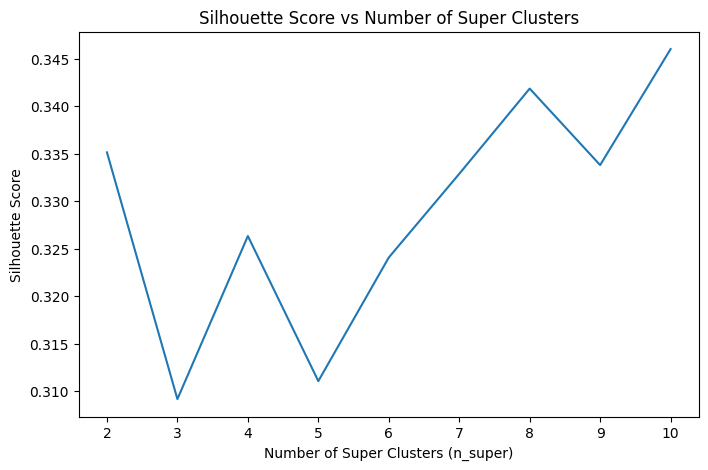

In [34]:
df_scores.sort_values("silhouette", ascending=False)

plt.figure(figsize=(8, 5))
plt.plot(df_scores['n_super'], df_scores['silhouette'])
plt.title("Silhouette Score vs Number of Super Clusters")
plt.xlabel("Number of Super Clusters (n_super)")
plt.ylabel("Silhouette Score")
plt.show()
